# Half-Edge Rank Lambda Comparison

Read the white/black CBSA tract output, sample a manageable set of metro areas, and compare half-edge rank values across lambda settings in two ways: ordinal rank vs. ordinal rank, and metric value vs. metric value.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [9]:
OUTPUT_CSV = Path("../outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_black.csv")
ANGLE = "angle_1"
N_SAMPLE_METROS = 30
RANDOM_STATE = 7

df = pd.read_csv(OUTPUT_CSV)
df["year"] = df["filename"].str.extract(r"study_areas/(\d{4})/").astype(int)
df["cbsa"] = df["filename"].str.extract(r"tracts_in_cbsa_(\d+)_")

df.head()

,filename,x_col,y_col,tot_col,angle_1,angle_2,skew,edge_lam_0_angle_1,half_edge_lam_0_angle_1,edge_lam_0_angle_2,...,total_population,total_white,total_poc,total_black,total_x,total_y,total_nodes,total_edges,year,cbsa
0,study_areas/2020/tracts_in_cbsa_42700_2020_mar...,BLACK,WHITE,TOTPOP,108942272,5.445239e+07,0.086223,0.435573,0.514135,0.435573,...,101235,65511,35724,9484,0.093683,0.647118,33,78,2020,42700
1,study_areas/2020/tracts_in_cbsa_23900_2020_mar...,BLACK,WHITE,TOTPOP,29548328,1.475131e+07,0.011807,0.489143,0.502743,0.489143,...,103852,89945,13907,1473,0.014184,0.866088,27,58,2020,23900
2,study_areas/2020/tracts_in_cbsa_22520_2020_mar...,BLACK,WHITE,TOTPOP,312484856,1.562079e+08,0.097065,0.435016,0.521502,0.435016,...,150791,119732,31059,18386,0.121930,0.794026,41,101,2020,22520
3,study_areas/2020/tracts_in_cbsa_14540_2020_mar...,BLACK,WHITE,TOTPOP,281234712,1.405792e+08,0.083387,0.457954,0.529320,0.457954,...,179639,139587,40052,13121,0.073041,0.777042,44,107,2020,14540
4,study_areas/2020/tracts_in_cbsa_43300_2020_mar...,BLACK,WHITE,TOTPOP,144062167,7.200542e+07,0.054532,0.457558,0.512479,0.457558,...,135543,95211,40332,7448,0.054949,0.702441,30,72,2020,43300


In [10]:
lambda_columns = {
    "0": f"half_edge_lam_0_{ANGLE}",
    "0.5": f"half_edge_lam_0_5_{ANGLE}",
    "1": f"half_edge_lam_1_{ANGLE}",
    "2": f"half_edge_lam_2_{ANGLE}",
    "10": f"half_edge_lam_10_{ANGLE}",
    "infinity": f"half_edge_lam_lim_{ANGLE}",
}

missing_columns = [column for column in lambda_columns.values() if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing expected columns for {ANGLE}: {missing_columns}")

sampled_cbsas = (
    df[["cbsa"]]
    .drop_duplicates()
    .sample(n=min(N_SAMPLE_METROS, df["cbsa"].nunique()), random_state=RANDOM_STATE)
    ["cbsa"]
)

plot_df = df.loc[df["cbsa"].isin(sampled_cbsas), ["filename", "year", "cbsa", *lambda_columns.values()]].copy()
plot_df = plot_df.sort_values(lambda_columns["1"]).reset_index(drop=True)
plot_df["lambda_1_rank"] = plot_df.index + 1
plot_df["lambda_1_value"] = plot_df[lambda_columns["1"]]

plot_df = plot_df.melt(
    id_vars=["filename", "year", "cbsa", "lambda_1_rank", "lambda_1_value"],
    value_vars=list(lambda_columns.values()),
    var_name="lambda_column",
    value_name="half_edge_rank",
)
plot_df["lambda"] = plot_df["lambda_column"].map({column: lam for lam, column in lambda_columns.items()})
plot_df["lambda"] = pd.Categorical(plot_df["lambda"], categories=list(lambda_columns), ordered=True)
plot_df["lambda_rank"] = plot_df.groupby("lambda", observed=True)["half_edge_rank"].rank(method="first")

plot_df.head()

,filename,year,cbsa,lambda_1_rank,lambda_1_value,lambda_column,half_edge_rank,lambda,lambda_rank
0,study_areas/2020/tracts_in_cbsa_16220_2020_mar...,2020,16220,1,0.500062,half_edge_lam_0_angle_1,0.499877,0,7.0
1,study_areas/1980/tracts_in_cbsa_11540_1980_mar...,1980,11540,2,0.500138,half_edge_lam_0_angle_1,0.500076,0,8.0
2,study_areas/1980/tracts_in_cbsa_32580_1980_mar...,1980,32580,3,0.500285,half_edge_lam_0_angle_1,0.499685,0,4.0
3,study_areas/2000/tracts_in_cbsa_16220_2000_mar...,2000,16220,4,0.500351,half_edge_lam_0_angle_1,0.499792,0,6.0
4,study_areas/1980/tracts_in_cbsa_13740_1980_mar...,1980,13740,5,0.500390,half_edge_lam_0_angle_1,0.500183,0,9.0


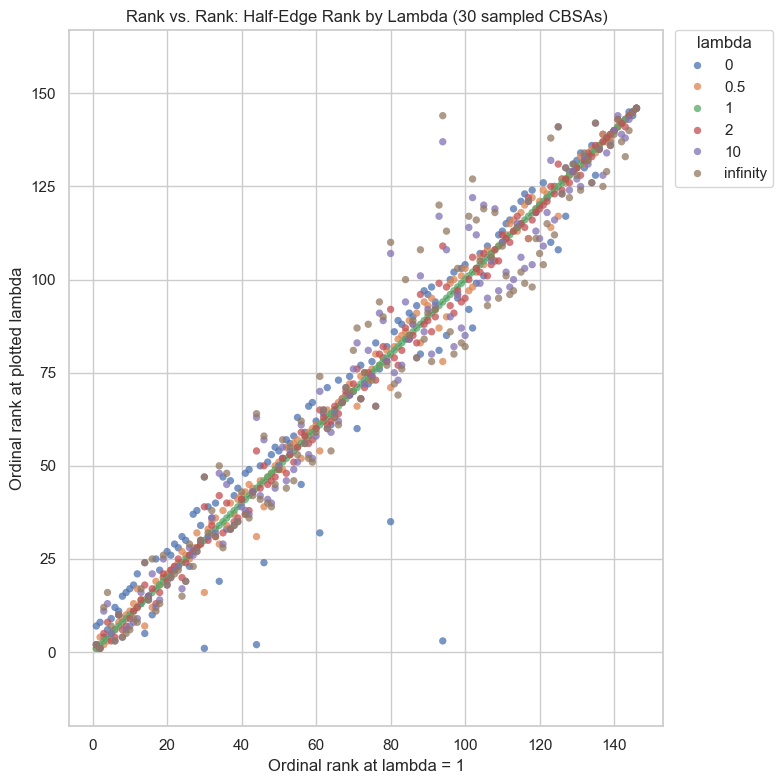

In [14]:
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(8, 8))
sns.scatterplot(
    # choose only lambda values of 0, 0.5, 1:
    data=plot_df,#[plot_df["lambda"].isin(["0", "0.5", "1"])],
    x="lambda_1_rank",
    y="lambda_rank",
    hue="lambda",
    hue_order=list(lambda_columns),
    s=28,
    alpha=0.75,
    linewidth=0,
)

rank_max = plot_df["lambda_1_rank"].max()
plt.plot([1, rank_max], [1, rank_max], color="0.35", linestyle="--", linewidth=1, zorder=0)
plt.xlabel("Ordinal rank at lambda = 1")
plt.ylabel("Ordinal rank at plotted lambda")
plt.title(f"Rank vs. Rank: Half-Edge Rank by Lambda ({len(sampled_cbsas)} sampled CBSAs)")
plt.legend(title="lambda", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.axis("equal")
plt.tight_layout()
plt.show()

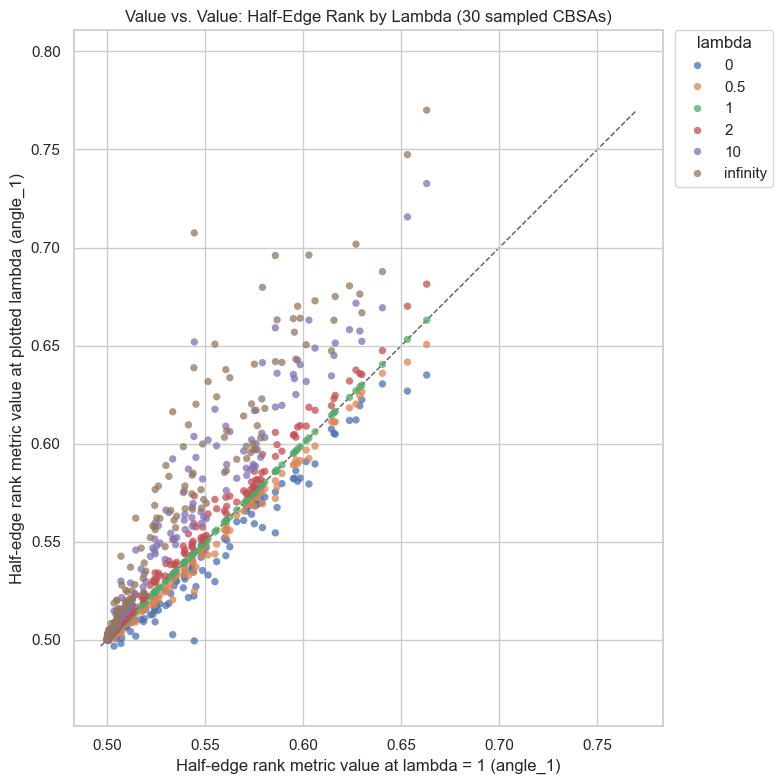

In [15]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=plot_df,
    x="lambda_1_value",
    y="half_edge_rank",
    hue="lambda",
    hue_order=list(lambda_columns),
    s=28,
    alpha=0.75,
    linewidth=0,
)

value_min = min(plot_df["lambda_1_value"].min(), plot_df["half_edge_rank"].min())
value_max = max(plot_df["lambda_1_value"].max(), plot_df["half_edge_rank"].max())
plt.plot([value_min, value_max], [value_min, value_max], color="0.35", linestyle="--", linewidth=1, zorder=0)
plt.xlabel(f"Half-edge rank metric value at lambda = 1 ({ANGLE})")
plt.ylabel(f"Half-edge rank metric value at plotted lambda ({ANGLE})")
plt.title(f"Value vs. Value: Half-Edge Rank by Lambda ({len(sampled_cbsas)} sampled CBSAs)")
plt.legend(title="lambda", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.axis("equal")
plt.tight_layout()
plt.show()